## Section 1: Setup & Environment

In [26]:
# Imports and environment
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import time

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

PyTorch: 2.11.0+cu130
CUDA: True
Device: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM total: 3.68 GB


## Section 2: Model Loading & VRAM Profile

In [27]:
# Model yükle ve VRAM ölç
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

mem_before = torch.cuda.memory_allocated() / 1024**2

MODEL_ID = "IDEA-Research/grounding-dino-tiny"
DEVICE = "cuda"

print("Loading processor...")
processor = AutoProcessor.from_pretrained(MODEL_ID)

print("Loading model (first run downloads ~700MB)...")
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

mem_after = torch.cuda.memory_allocated() / 1024**2
print(f"\nVRAM used by model: {mem_after - mem_before:.1f} MB")
print(f"Total VRAM allocated: {mem_after:.1f} MB")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Loading processor...
Loading model (first run downloads ~700MB)...

VRAM used by model: 2.5 MB
Total VRAM allocated: 783.7 MB
Model parameters: 172.2M


## Section 3: First Inference

Image size (W, H): (640, 480)


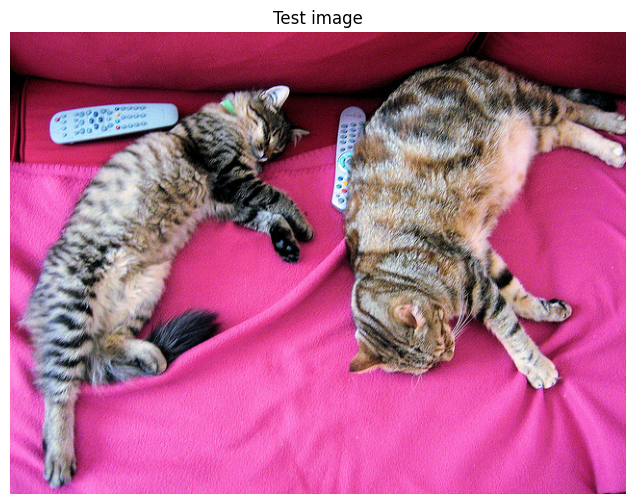

In [28]:
# First inference
import requests
from io import BytesIO

# COCO test image — kedi ve uzaktan kumanda
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
print(f"Image size (W, H): {image.size}")

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Test image")
plt.show()

## Section 4: Detection

In [29]:
# Hücre 4: Detection
text_prompts = "a cat. a remote control."

inputs = processor(images=image, text=text_prompts, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

# Yeni API: tek bir 'threshold' parametresi, input_ids ayrı geçilmiyor
results = processor.post_process_grounded_object_detection(
    outputs,
    threshold=0.4,                      # eski 'box_threshold' yerine
    target_sizes=[image.size[::-1]],    # PIL (W,H) → (H,W)
    text_labels=[["a cat", "a remote control"]],  # opsiyonel ama önerilir
)

result = results[0]
print(f"Number of detections: {len(result['boxes'])}")
print(f"\nBoxes:\n{result['boxes']}")
print(f"\nScores: {result['scores']}")
print(f"\nLabels (integer ids): {result['labels']}")
print(f"\nText labels: {result.get('text_labels', 'N/A')}")

Number of detections: 3

Boxes:
tensor([[344.6933,  23.1090, 637.1844, 374.2747],
        [ 12.2651,  51.9149, 316.8590, 472.4387],
        [ 38.5835,  70.0063, 176.7782, 118.1764]], device='cuda:0')

Scores: tensor([0.4785, 0.4381, 0.4759], device='cuda:0')

Labels (integer ids): ['a cat', 'a cat', 'a remote control']

Text labels: ['a cat', 'a cat', 'a remote control']


## Section 5: Visualization

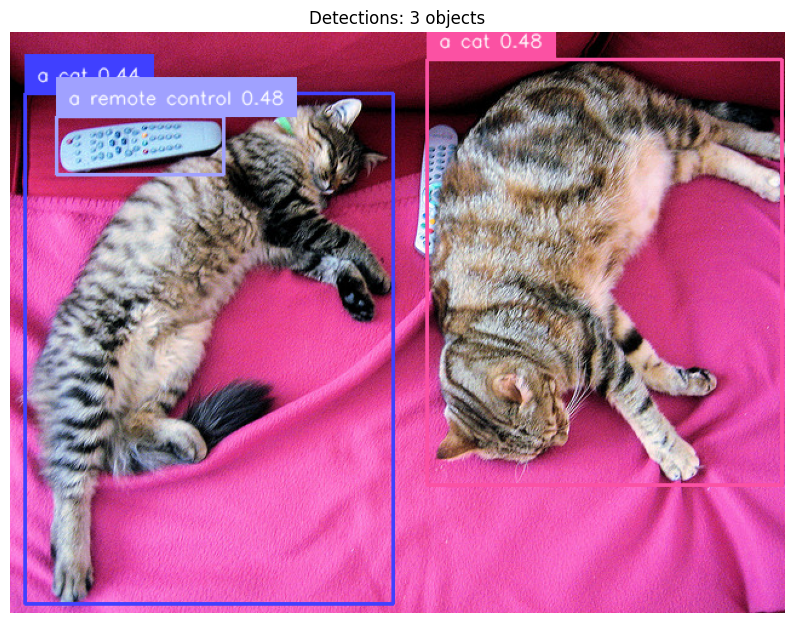

In [30]:
# Visualize
import supervision as sv

detections = sv.Detections(
    xyxy=result["boxes"].cpu().numpy(),
    confidence=result["scores"].cpu().numpy(),
    class_id=np.arange(len(result["labels"])),
)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated = np.array(image)
annotated = box_annotator.annotate(annotated, detections)
labels = [f"{lbl} {conf:.2f}" for lbl, conf in zip(result["labels"], result["scores"])]
annotated = label_annotator.annotate(annotated, detections, labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(annotated)
plt.axis("off")
plt.title(f"Detections: {len(detections)} objects")
plt.show()

## Section 6: Threshold Sensitivity Analysis

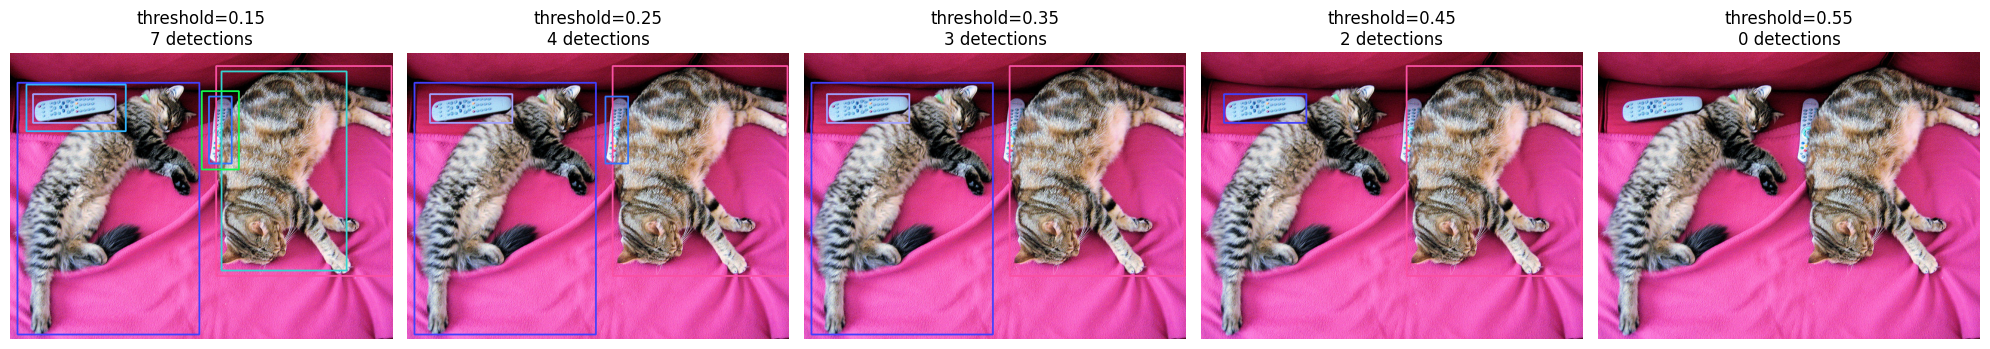

In [31]:
# Threshold sweep
thresholds_to_try = [0.15, 0.25, 0.35, 0.45, 0.55]

fig, axes = plt.subplots(1, len(thresholds_to_try), figsize=(20, 5))

for ax, thr in zip(axes, thresholds_to_try):
    res = processor.post_process_grounded_object_detection(
        outputs,
        threshold=thr,
        target_sizes=[image.size[::-1]],
        text_labels=[["a cat", "a remote control"]],
    )[0]
    
    if len(res["boxes"]) > 0:
        dets = sv.Detections(
            xyxy=res["boxes"].cpu().numpy(),
            confidence=res["scores"].cpu().numpy(),
            class_id=np.arange(len(res["boxes"])),
        )
        img_annotated = box_annotator.annotate(np.array(image).copy(), dets)
    else:
        img_annotated = np.array(image)
    
    ax.imshow(img_annotated)
    ax.set_title(f"threshold={thr}\n{len(res['boxes'])} detections")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Section 7: Compound Query Behavior

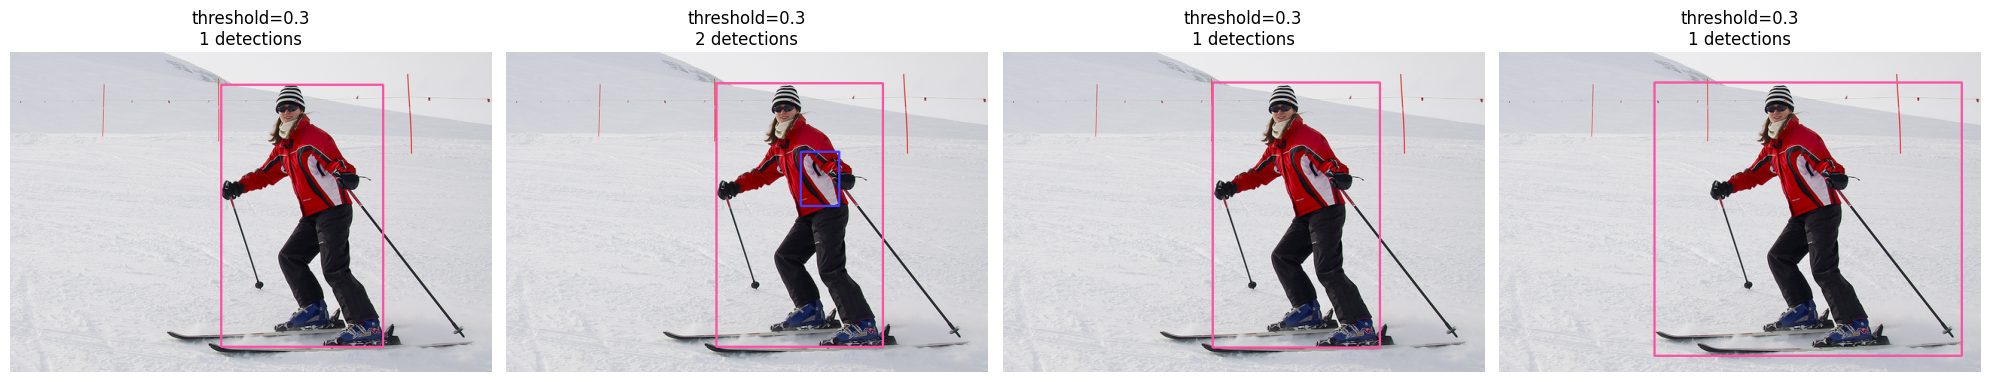

In [36]:
# Compound queries
url2 = "http://images.cocodataset.org/val2017/000000000785.jpg"
image2 = Image.open(BytesIO(requests.get(url2).content)).convert("RGB")
THRESHOLD = 0.3

queries_to_test = [
    "person.",
    "person wearing white shirt.",
    "person sitting down.",
    "small object.",  # vague — nasıl davranıyor?
]

# Her query için ayrı inference, sonuçları yan yana görselleştir
# Buradan itibaren sen yaz — dene, gör, yorumla

fig, axes = plt.subplots(1, len(queries_to_test), figsize=(20, 5))

for ax, query in zip(axes, queries_to_test):
    inputs2 = processor(images=image2, text=query, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs2 = model(**inputs2)

    res = processor.post_process_grounded_object_detection(
        outputs2,
        threshold=THRESHOLD,
        target_sizes=[image2.size[::-1]],
        text_labels=[[query]],
    )[0]
    
    if len(res["boxes"]) > 0:
        dets = sv.Detections(
            xyxy=res["boxes"].cpu().numpy(),
            confidence=res["scores"].cpu().numpy(),
            class_id=np.arange(len(res["boxes"])),
        )
        img_annotated = box_annotator.annotate(np.array(image2).copy(), dets)
    else:
        img_annotated = np.array(image2)
    
    ax.imshow(img_annotated)
    ax.set_title(f"threshold={THRESHOLD}\n{len(res['boxes'])} detections")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Section 8: Latency Benchmark

In [38]:
# Latency benchmark
N_RUNS = 20

# Warmup
for _ in range(3):
    with torch.no_grad():
        _ = model(**inputs)

torch.cuda.synchronize()

times = []
for _ in range(N_RUNS):
    torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        _ = model(**inputs)
    torch.cuda.synchronize()
    times.append(time.perf_counter() - start)

times = np.array(times) * 1000
print(f"Latency over {N_RUNS} runs:")
print(f"  Mean:   {times.mean():.1f} ms")
print(f"  Median: {np.median(times):.1f} ms")
print(f"  Min:    {times.min():.1f} ms")
print(f"  Max:    {times.max():.1f} ms")
print(f"  Std:    {times.std():.1f} ms")
print(f"\nApprox FPS (this image, fp32): {1000/times.mean():.1f}")

Latency over 20 runs:
  Mean:   435.5 ms
  Median: 435.5 ms
  Min:    433.6 ms
  Max:    437.4 ms
  Std:    1.1 ms

Approx FPS (this image, fp32): 2.3


### Observations

**Test image:** Single skier in red jacket on snow, holding ski poles.

**Per-query findings:**

- `person.` (1 detection): The model produced a single tight bounding box around the entire skier. This is the canonical case — generic noun, common class, model performs as expected.

- `person wearing white shirt.` (2 detections): The model returned two boxes: one around the entire skier and another smaller box around the upper torso. The second box likely corresponds to the "white shirt" attribute, but it's not a perfect match — it includes parts of the jacket and doesn't isolate just the shirt. This shows that the model can pick up on visual cues related to the query but doesn't have a true semantic understanding of clothing items.

- `person sitting down.` (1 detection): The model returned a single box around the entire skier, similar to the "person" query. The bounding box is quite similar to the generic "person" case, indicating the model focuses on the dominant visual features of the person rather than the specific action of sitting. This suggests that the model doesn't have a strong understanding of the "sitting" attribute in this context, likely because the skier is not actually sitting and the visual cues for sitting are not present.

- `small object.` (1 detection): The model returned much larger box around the entire skier, which is a false positive. It didn't detect any small object like ski poles or goggles. This indicates that the model struggles with vague queries and may return irrelevant detections if the query is not specific enough.

**Key takeaways for pipeline design:**

1. The model treats the additional details as soft constraints, not hard filters. This allows for flexible matching but can lead to false positives if the query is too specific or ambiguous.

2. Model can't match the attributes entirely semantic. It doesn't understand "white shirt" as a clothing item, but rather as a visual pattern. This can lead to unexpected matches based on color and texture rather than semantic meaning.

3. When given a vague query like 'small object', the model returned a single huge bbox covering most of the image instead of either returning nothing or localizing actually small items in the scene. This is a failure mode worth guarding against — pipelines should sanity-check bbox area against image area to filter out 'shrug' detections.

**Latency context:** RTX 3050 Ti Laptop, fp32, single image (~640px), grounding-dino-tiny: 
mean 433.9 ms (2.3 FPS). Real-time video processing requires keyframe strategy 
where detector runs every N frames.